
Author: Prof. Manoel Gadi

Contact: mfalonso@faculty.ie.edu

Teaching Web: https://github.com/manoelgadi

Last revision: 10/May/2026

# Lifetime Value Modeling for Banks

This notebook demonstrates a simplified approach to **Customer Lifetime Value (LTV) modeling** in banking.

The example combines:

1. A **churn / attrition model** to estimate whether a customer may leave the bank.
2. A **revenue model** to estimate one-year expected revenue.
3. A **Markov transition matrix** to simulate how customers migrate between value and risk states over time.
4. A **20-year discounted Lifetime Value calculation**.

The goal is not to create a production-ready banking model, but to show the logic behind combining predictive modeling with long-term portfolio value estimation.

## 1. Create a Synthetic Banking Dataset

We first create a synthetic dataset representing bank customers.

The dataset includes variables that could be relevant for both:

- **Churn / attrition modeling**: whether the customer may cancel the account.
- **Revenue modeling**: how much revenue the customer may generate over one year.

The dataset includes demographic variables, behavioral variables, relationship variables, and risk-related variables.

In [97]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 5000

df = pd.DataFrame({
    "customer_id": range(1, n + 1),
    "age": np.random.randint(18, 75, n),
    "income": np.random.normal(45000, 15000, n).clip(10000, 150000),
    "tenure_years": np.random.randint(0, 15, n),
    "num_products": np.random.randint(1, 6, n),
    "monthly_transactions": np.random.poisson(25, n),
    "avg_balance": np.random.normal(6000, 4000, n).clip(0, 50000),
    "credit_score": np.random.normal(680, 80, n).clip(300, 850),
    "complaints": np.random.poisson(0.4, n),
    "digital_usage_score": np.random.uniform(0, 1, n)
})

df.head()

,customer_id,age,income,tenure_years,num_products,monthly_transactions,avg_balance,credit_score,complaints,digital_usage_score
0,1,56,54277.325707,2,4,26,3040.305086,766.616782,1,0.961887
1,2,69,41887.837160,0,1,26,7020.492352,634.391007,0,0.727125
2,3,46,54429.378493,10,5,32,7057.205656,540.619282,0,0.975344
3,4,32,25959.071901,7,1,22,15473.573873,792.073182,0,0.927366
4,5,60,34564.929332,13,1,27,7253.005039,694.669440,2,0.610749


## 1.1 Create the Churn / Attrition Target

The churn variable represents whether the customer leaves the bank.

In this synthetic example, churn is more likely when:

- The customer has lower tenure.
- The customer has fewer products.
- The customer has a lower average balance.
- The customer has more complaints.
- The customer has lower digital engagement.

This is only a simulation, but it follows a realistic business logic.

In [98]:
churn_score = (
    -0.03 * df["tenure_years"]
    -0.25 * df["num_products"]
    -0.00002 * df["avg_balance"]
    +0.5 * df["complaints"]
    -0.8 * df["digital_usage_score"]
    + np.random.normal(0, 0.5, n)
)

df["churn_probability_true"] = 1 / (1 + np.exp(-churn_score))
df["churn"] = np.random.binomial(1, df["churn_probability_true"])

df.head()

,customer_id,age,income,tenure_years,num_products,monthly_transactions,avg_balance,credit_score,complaints,digital_usage_score,churn_probability_true,churn
0,1,56,54277.325707,2,4,26,3040.305086,766.616782,1,0.961887,0.196993,0
1,2,69,41887.837160,0,1,26,7020.492352,634.391007,0,0.727125,0.173241,1
2,3,46,54429.378493,10,5,32,7057.205656,540.619282,0,0.975344,0.146995,0
3,4,32,25959.071901,7,1,22,15473.573873,792.073182,0,0.927366,0.121762,0
4,5,60,34564.929332,13,1,27,7253.005039,694.669440,2,0.610749,0.383158,0


## 1.2 Create the Default Target

Default is included as a terminal negative outcome in the Lifetime Value model.

A customer who defaults is assumed to produce a significant financial loss for the bank.

In this synthetic example, default is more likely when:

- The customer has a lower credit score.
- The customer has lower income.
- The customer has more complaints.

In [99]:
default_score = (
    -0.008 * df["credit_score"]
    -0.00001 * df["income"]
    +0.4 * df["complaints"]
    + np.random.normal(0, 0.7, n)
)

df["default_probability_true"] = 1 / (1 + np.exp(-default_score))
df["default"] = np.random.binomial(1, df["default_probability_true"])

df

,customer_id,age,income,tenure_years,num_products,monthly_transactions,avg_balance,credit_score,complaints,digital_usage_score,churn_probability_true,churn,default_probability_true,default
0,1,56,54277.325707,2,4,26,3040.305086,766.616782,1,0.961887,0.196993,0,0.001349,0
1,2,69,41887.837160,0,1,26,7020.492352,634.391007,0,0.727125,0.173241,1,0.011511,0
2,3,46,54429.378493,10,5,32,7057.205656,540.619282,0,0.975344,0.146995,0,0.014173,0
3,4,32,25959.071901,7,1,22,15473.573873,792.073182,0,0.927366,0.121762,0,0.002730,0
4,5,60,34564.929332,13,1,27,7253.005039,694.669440,2,0.610749,0.383158,0,0.009842,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,67,54550.052305,7,1,29,2570.447600,584.009935,0,0.024545,0.346865,1,0.004036,0
4996,4997,39,48023.701713,11,5,25,5675.151961,532.898717,0,0.563959,0.167461,0,0.034897,0
4997,4998,46,46482.891675,0,4,28,798.081516,708.964399,0,0.879573,0.095506,0,0.002298,0
4998,4999,39,82612.428568,3,3,22,6957.056702,726.529020,1,0.860850,0.128824,0,0.004068,0


## 1.3 Create One-Year Revenue

Revenue represents the expected annual revenue from each customer.

In this example, revenue increases with:

- More products.
- Higher average balance.
- More monthly transactions.
- Higher digital usage.

Revenue decreases with complaints.

In [100]:
df["annual_revenue"] = (
    50
    + 12 * df["num_products"]
    + 0.015 * df["avg_balance"]
    + 1.5 * df["monthly_transactions"]
    + 80 * df["digital_usage_score"]
    - 30 * df["complaints"]
    + np.random.normal(0, 80, n)
).clip(-200, 2000)

df[["customer_id", "annual_revenue"]].head()

,customer_id,annual_revenue
0,1,229.592584
1,2,215.841196
2,3,306.532002
3,4,423.366485
4,5,251.452774


## 2. Build the Churn Model and Revenue Model

Now we train two models:

1. A **classification model** to estimate churn probability.
2. A **regression model** to estimate annual revenue.

For simplicity, we use Random Forest models. In a real bank, model selection would also consider explainability, regulation, monitoring, validation, and model risk governance.

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import roc_auc_score, mean_absolute_error

features = [
    "age", "income", "tenure_years", "num_products",
    "monthly_transactions", "avg_balance",
    "credit_score", "complaints", "digital_usage_score"
]

X = df[features]

## 2.1 Churn Model

The churn model estimates the probability that a customer will leave the bank.

The output is a probability between 0 and 1.

In [102]:
y_churn = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_churn, test_size=0.3, random_state=42
)

churn_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=6
)

churn_model.fit(X_train, y_train)

df["predicted_churn_probability"] = churn_model.predict_proba(X)[:, 1]

churn_auc = roc_auc_score(y_test, churn_model.predict_proba(X_test)[:, 1])
print("Churn AUC:", round(churn_auc, 4))

df[["customer_id", "predicted_churn_probability"]].head()

Churn AUC: 0.6166


,customer_id,predicted_churn_probability
0,1,0.208878
1,2,0.274095
2,3,0.127947
3,4,0.277261
4,5,0.373377


## 2.2 Revenue Model

The revenue model estimates the expected revenue generated by each customer in one year.

The output is a monetary value.

In [103]:
y_revenue = df["annual_revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_revenue, test_size=0.3, random_state=42
)

revenue_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=6
)

revenue_model.fit(X_train, y_train)

df["predicted_annual_revenue"] = revenue_model.predict(X)

revenue_mae = mean_absolute_error(y_test, revenue_model.predict(X_test))
print("Revenue MAE:", round(revenue_mae, 2))

df[["customer_id", "predicted_annual_revenue"]].head()

Revenue MAE: 64.75


,customer_id,predicted_annual_revenue
0,1,235.321893
1,2,280.411452
2,3,324.400742
3,4,388.896052
4,5,243.067568


## 3. Create Customer States

We now combine churn probability and expected revenue.

Each customer is assigned to:

- Low, Medium, or High Attrition.
- Low, Medium, or High Revenue.

This creates 9 possible customer states.

We also add two terminal states:

1. **Churn**: the customer leaves the bank.
2. **Default**: the customer produces a large loss.

In [104]:
df["attrition_group"] = pd.qcut(
    df["predicted_churn_probability"],
    q=3,
    labels=["Low Attrition", "Medium Attrition", "High Attrition"]
)

df["revenue_group"] = pd.qcut(
    df["predicted_annual_revenue"],
    q=3,
    labels=["Low Revenue", "Medium Revenue", "High Revenue"]
)

df["state"] = df["attrition_group"].astype(str) + " / " + df["revenue_group"].astype(str)

states = sorted(df["state"].unique().tolist())
terminal_states = ["Churn", "Default"]
all_states = states + terminal_states

df[["customer_id", "predicted_churn_probability", "predicted_annual_revenue", "state"]].head()

,customer_id,predicted_churn_probability,predicted_annual_revenue,state
0,1,0.208878,235.321893,Medium Attrition / Medium Revenue
1,2,0.274095,280.411452,High Attrition / High Revenue
2,3,0.127947,324.400742,Low Attrition / High Revenue
3,4,0.277261,388.896052,High Attrition / High Revenue
4,5,0.373377,243.067568,High Attrition / Medium Revenue


## 3.1 Define Profit or Loss by State

Each state receives a yearly financial value.

High-revenue customers produce more profit.

Customers with high attrition risk produce slightly less profit because the relationship is less stable.

Terminal states are treated differently:

- **Churn** produces only a small final profit.
- **Default** produces a large financial loss.

In [105]:
state_profit = {}

for state in states:
    if "Low Revenue" in state:
        base_profit = 10
    elif "Medium Revenue" in state:
        base_profit = 30
    else:
        base_profit = 70

    if "High Attrition" in state:
        base_profit *= 0.9

    state_profit[state] = base_profit

state_profit["Churn"] = 50       # small final profit
state_profit["Default"] = -150  # big loss

pd.DataFrame.from_dict(state_profit, orient="index", columns=["Annual Profit / Loss"])

,Annual Profit / Loss
High Attrition / High Revenue,63.0
High Attrition / Low Revenue,9.0
High Attrition / Medium Revenue,27.0
Low Attrition / High Revenue,70.0
Low Attrition / Low Revenue,10.0
Low Attrition / Medium Revenue,30.0
Medium Attrition / High Revenue,70.0
Medium Attrition / Low Revenue,10.0
Medium Attrition / Medium Revenue,30.0
Churn,50.0


## 3.2 Build the Markov Transition Matrix

A Markov matrix describes how customers move from one state to another over time.

For example, a customer may:

- Stay in the same state.
- Move to another attrition/revenue state.
- Churn.
- Default.

The terminal states are absorbing states:

- Once a customer churns, they remain in churn.
- Once a customer defaults, they remain in default.

In [106]:
transition_matrix = pd.DataFrame(
    0.0,
    index=all_states,
    columns=all_states
)

for state in states:

    if state == "Low Attrition / High Revenue":
        p_churn = 0.01
        p_default = 0.01
        stay_probability = 0.75

    elif "Low Attrition" in state:
        p_churn = 0.015
        p_default = 0.02
        stay_probability = 0.70

    elif "Medium Attrition" in state:
        p_churn = 0.04
        p_default = 0.04
        stay_probability = 0.60

    else:
        p_churn = 0.08
        p_default = 0.06
        stay_probability = 0.55

    remaining_prob = 1 - p_churn - p_default

    transition_matrix.loc[state, state] = remaining_prob * stay_probability

    other_states = [s for s in states if s != state]
    for other in other_states:
        transition_matrix.loc[state, other] = (
            remaining_prob * (1 - stay_probability) / len(other_states)
        )

    transition_matrix.loc[state, "Churn"] = p_churn
    transition_matrix.loc[state, "Default"] = p_default

transition_matrix.loc["Churn", "Churn"] = 1.0
transition_matrix.loc["Default", "Default"] = 1.0

transition_matrix.round(3)

,High Attrition / High Revenue,High Attrition / Low Revenue,High Attrition / Medium Revenue,Low Attrition / High Revenue,Low Attrition / Low Revenue,Low Attrition / Medium Revenue,Medium Attrition / High Revenue,Medium Attrition / Low Revenue,Medium Attrition / Medium Revenue,Churn,Default
High Attrition / High Revenue,0.473,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.080,0.06
High Attrition / Low Revenue,0.048,0.473,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.080,0.06
High Attrition / Medium Revenue,0.048,0.048,0.473,0.048,0.048,0.048,0.048,0.048,0.048,0.080,0.06
Low Attrition / High Revenue,0.031,0.031,0.031,0.735,0.031,0.031,0.031,0.031,0.031,0.010,0.01
Low Attrition / Low Revenue,0.036,0.036,0.036,0.036,0.676,0.036,0.036,0.036,0.036,0.015,0.02
Low Attrition / Medium Revenue,0.036,0.036,0.036,0.036,0.036,0.676,0.036,0.036,0.036,0.015,0.02
Medium Attrition / High Revenue,0.046,0.046,0.046,0.046,0.046,0.046,0.552,0.046,0.046,0.040,0.04
Medium Attrition / Low Revenue,0.046,0.046,0.046,0.046,0.046,0.046,0.046,0.552,0.046,0.040,0.04
Medium Attrition / Medium Revenue,0.046,0.046,0.046,0.046,0.046,0.046,0.046,0.046,0.552,0.040,0.04
Churn,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.00


In [107]:
transition_matrix.T.sum()

High Attrition / High Revenue        1.0
High Attrition / Low Revenue         1.0
High Attrition / Medium Revenue      1.0
Low Attrition / High Revenue         1.0
Low Attrition / Low Revenue          1.0
Low Attrition / Medium Revenue       1.0
Medium Attrition / High Revenue      1.0
Medium Attrition / Low Revenue       1.0
Medium Attrition / Medium Revenue    1.0
Churn                                1.0
Default                              1.0
dtype: float64

## 3.3 Validate the Transition Matrix

Each row of a transition matrix should sum to 1.

This means each customer must move somewhere after each year.

In [108]:
row_sums = transition_matrix.sum(axis=1)

pd.DataFrame({
    "state": row_sums.index,
    "row_sum": row_sums.values
})

,state,row_sum
0,High Attrition / High Revenue,1.0
1,High Attrition / Low Revenue,1.0
2,High Attrition / Medium Revenue,1.0
3,Low Attrition / High Revenue,1.0
4,Low Attrition / Low Revenue,1.0
5,Low Attrition / Medium Revenue,1.0
6,Medium Attrition / High Revenue,1.0
7,Medium Attrition / Low Revenue,1.0
8,Medium Attrition / Medium Revenue,1.0
9,Churn,1.0


## 4. Calculate 20-Year Customer Lifetime Value

We now simulate the portfolio over 20 years.

Each year:

1. We calculate the expected profit from the current state distribution.
2. We discount that profit to present value.
3. We move customers to next year's states using the Markov matrix.

The result is the expected discounted Lifetime Value of the customer portfolio.

In [109]:
state_distribution

array([0.01761024, 0.01761024, 0.01761024, 0.03946574, 0.03066549,
       0.03066549, 0.02099941, 0.02099941, 0.02100062, 0.4081133 ,
       0.3752598 ])

In [110]:
transition_matrix.values

array([[0.473    , 0.048375 , 0.048375 , 0.048375 , 0.048375 , 0.048375 ,
        0.048375 , 0.048375 , 0.048375 , 0.08     , 0.06     ],
       [0.048375 , 0.473    , 0.048375 , 0.048375 , 0.048375 , 0.048375 ,
        0.048375 , 0.048375 , 0.048375 , 0.08     , 0.06     ],
       [0.048375 , 0.048375 , 0.473    , 0.048375 , 0.048375 , 0.048375 ,
        0.048375 , 0.048375 , 0.048375 , 0.08     , 0.06     ],
       [0.030625 , 0.030625 , 0.030625 , 0.735    , 0.030625 , 0.030625 ,
        0.030625 , 0.030625 , 0.030625 , 0.01     , 0.01     ],
       [0.0361875, 0.0361875, 0.0361875, 0.0361875, 0.6755   , 0.0361875,
        0.0361875, 0.0361875, 0.0361875, 0.015    , 0.02     ],
       [0.0361875, 0.0361875, 0.0361875, 0.0361875, 0.0361875, 0.6755   ,
        0.0361875, 0.0361875, 0.0361875, 0.015    , 0.02     ],
       [0.046    , 0.046    , 0.046    , 0.046    , 0.046    , 0.046    ,
        0.552    , 0.046    , 0.046    , 0.04     , 0.04     ],
       [0.046    , 0.046    , 0.04

## Multiply the current probability distribution vector by the transition matrix.

P * M

where M (as from -> to)

In [111]:
state_distribution @ transition_matrix.values

array([0.01635946, 0.01635946, 0.01635946, 0.03668039, 0.02848655,
       0.02848655, 0.01950742, 0.01950742, 0.01950803, 0.41617436,
       0.3825709 ])

or M(transposed) * P

where M (as to -> from)

In [116]:
transition_matrix.T.values @ state_distribution 

array([0.01635946, 0.01635946, 0.01635946, 0.03668039, 0.02848655,
       0.02848655, 0.01950742, 0.01950742, 0.01950803, 0.41617436,
       0.3825709 ])

In [112]:
discount_rate = 0.08
years = 20

profit_vector = np.array([state_profit[s] for s in all_states])

ltv_by_year = []

for initial_state in states:

    # Start with 100% probability in one specific initial state
    state_distribution = np.zeros(len(all_states))
    state_distribution[all_states.index(initial_state)] = 1.0

    cumulative_ltv = 0

    for year in range(1, years + 1):

        expected_profit = np.dot(state_distribution, profit_vector)
        discounted_profit = expected_profit / ((1 + discount_rate) ** year)

        cumulative_ltv += discounted_profit

        ltv_by_year.append({
            "initial_state": initial_state,
            "year": year,
            "expected_profit": expected_profit,
            "discounted_profit": discounted_profit,
            "cumulative_ltv": cumulative_ltv,
            "probability_churned": state_distribution[all_states.index("Churn")],
            "probability_defaulted": state_distribution[all_states.index("Default")]
        })

        # Move to next year
        state_distribution = state_distribution @ transition_matrix.values

ltv_results = pd.DataFrame(ltv_by_year)



In [113]:
ltv_results

,initial_state,year,expected_profit,discounted_profit,cumulative_ltv,probability_churned,probability_defaulted
0,High Attrition / High Revenue,1,63.000000,58.333333,58.333333,0.000000,0.000000
1,High Attrition / High Revenue,2,37.183000,31.878429,90.211763,0.080000,0.060000
2,High Attrition / High Revenue,3,23.523574,18.673772,108.885534,0.133320,0.102409
3,High Attrition / High Revenue,4,15.330922,11.268685,120.154220,0.172568,0.135167
4,High Attrition / High Revenue,5,9.686589,6.592529,126.746749,0.203916,0.162233
...,...,...,...,...,...,...,...
175,Medium Attrition / Medium Revenue,16,-19.922477,-5.815181,61.237777,0.357547,0.329398
176,Medium Attrition / Medium Revenue,17,-21.746585,-5.877427,55.360350,0.369208,0.339974
177,Medium Attrition / Medium Revenue,18,-23.441717,-5.866267,49.494083,0.380037,0.349795
178,Medium Attrition / Medium Revenue,19,-25.016926,-5.796724,43.697359,0.390094,0.358917


## To see the final 20-year LTV for each starting state:

In [114]:
final_ltv_by_state = (
    ltv_results[ltv_results["year"] == years]
    [["initial_state", "cumulative_ltv"]]
    .sort_values("cumulative_ltv", ascending=False)
    .reset_index(drop=True)
)

final_ltv_by_state

,initial_state,cumulative_ltv
0,Low Attrition / High Revenue,217.775829
1,Medium Attrition / High Revenue,107.702379
2,Low Attrition / Medium Revenue,75.568080
3,High Attrition / High Revenue,70.335015
4,Medium Attrition / Medium Revenue,38.015986
5,Low Attrition / Low Revenue,30.185713
6,High Attrition / Medium Revenue,15.404632
7,Medium Attrition / Low Revenue,3.172789
8,High Attrition / Low Revenue,-12.060559


## 4.1 Plot Lifetime Value Evolution

The chart shows how expected cumulative Lifetime Value evolves over 20 years.

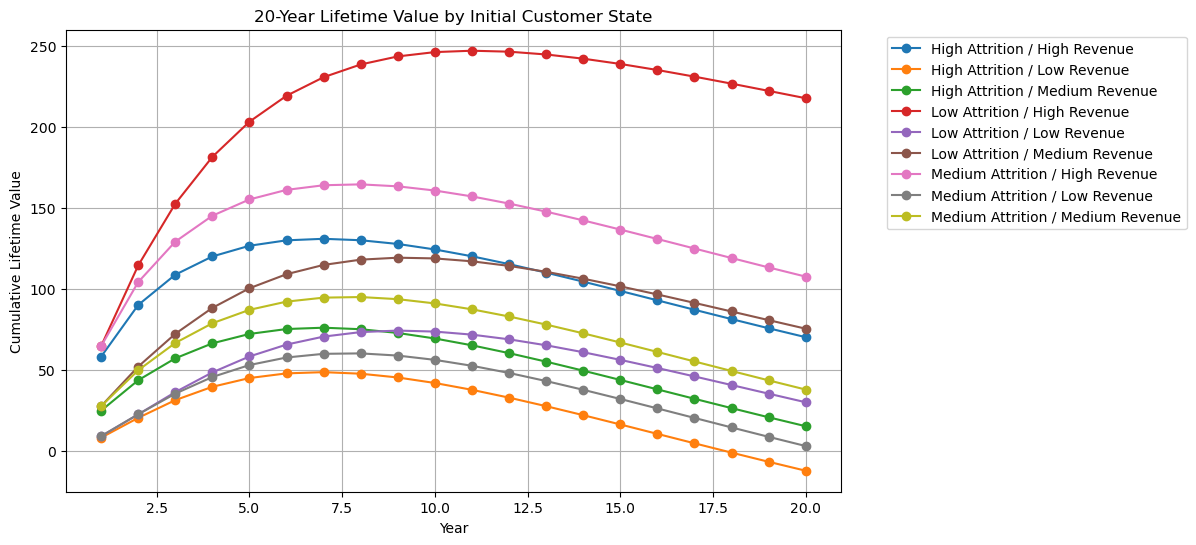

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for initial_state in states:
    temp = ltv_results[ltv_results["initial_state"] == initial_state]
    plt.plot(temp["year"], temp["cumulative_ltv"], marker="o", label=initial_state)

plt.xlabel("Year")
plt.ylabel("Cumulative Lifetime Value")
plt.title("20-Year Lifetime Value by Initial Customer State")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

## Final Interpretation

This notebook shows how banks can combine predictive models with long-term financial simulation.

The main idea is:

- The churn model estimates the probability of losing a customer.
- The revenue model estimates how much value the customer may create.
- The Markov matrix estimates how customer states change over time.
- The Lifetime Value calculation converts future profits and losses into today's value.

This type of framework can help banks think about:

- Customer retention.
- Profitability.
- Default risk.
- Long-term portfolio value.
- Strategic investment in customer relationships.

# How a FinTech could use this to beat banks

A FinTech could use this type of **Lifetime Value + Markov migration framework** to compete with banks in a very strategic way, because most traditional banks still optimize mainly around:

* short-term profitability,
* product silos,
* static segmentation,
* and quarterly KPIs.

A more advanced FinTech could optimize around the **future evolution of the customer relationship**.


### 1. Acquire customers banks reject or undervalue

Traditional banks often use:

* rigid scorecards,
* static segments,
* backward-looking rules.

But a FinTech using dynamic LTV modeling could identify:

* customers with temporarily low profitability,
* but high future migration potential.

For example:

* a student today,
* but likely future high-income customer.

So instead of asking:

> “Is this customer profitable today?”

the FinTech asks:

> “What is the expected 10-year migration path of this customer?”

That is a huge competitive difference.

---

## 2. Optimize retention dynamically

Banks often use generic retention campaigns.

A FinTech could predict:

* which customers are about to migrate into:

  * high attrition,
  * low profitability,
  * or default states.

Then intervene early:

* personalized pricing,
* incentives,
* product offers,
* financial coaching,
* AI-driven engagement.

This becomes:

> proactive relationship management instead of reactive retention.

---

## 3. Cross-sell only when migration probability is favorable

Most banks spam cross-selling.

A better approach:

* estimate:

  * “If I offer product X, does the customer migrate to a better future state?”

Meaning:

* product recommendation becomes:

  * a state-transition optimization problem.

This is much more advanced.

---

## 4. Price risk more intelligently

Banks usually separate:

* credit risk,
* marketing,
* CRM,
* fraud,
* profitability.

A FinTech could unify all of them into:

* one dynamic customer-state engine.

This allows:

* personalized pricing,
* dynamic limits,
* adaptive onboarding,
* real-time risk adjustment.

---



# How to improve this model even further

Our current framework is already very strong conceptually, but here’s how advanced firms improve it.

---

# 1. Move from static Markov to dynamic Markov

Right now transitions are fixed:

```python
P(next_state | current_state)
```

But reality changes.

Better:

```python
P(next_state | current_state, macroeconomy, behavior, fraud, seasonality)
```

Meaning transitions become:

* contextual,
* time-dependent,
* adaptive.

This is a huge improvement.

---

# 2. Use survival analysis instead of simple churn probabilities

Instead of:

* “Will churn happen?”

estimate:

* “When will churn happen?”

Using:

* Cox models,
* Kaplan-Meier,
* Deep Survival Models.

Very powerful in banking.

---

# 3. Add reinforcement learning

This is where things become really advanced.

Instead of predicting:

* customer evolution,

the AI learns:

* the best action to maximize future LTV.

Meaning:

* which offer,
* which intervention,
* which timing,
* which product,
* for each customer state.

This becomes:

> AI-driven customer strategy optimization.

Huge competitive advantage.

---

# 4. Include network effects

Banks model customers individually.

But fraud, churn, and default are often network phenomena.

A better model:

* graph-based customer relationships,
* shared devices,
* merchants,
* social clusters,
* family structures.

This becomes:

* graph AI + Markov + LTV.

Very powerful.

---

# 5. Include fraud as a dynamic state

Your model already touches this.

But advanced systems:

* treat fraud not as binary,
* but as evolving states:

  * suspicious,
  * mule,
  * synthetic identity,
  * compromised,
  * recovering.

Then fraud itself becomes:

* a migration problem.

---

# 6. Real-time updating

Banks still run many models monthly.

FinTech advantage:

* streaming data,
* real-time transition updates,
* online learning.

This creates:

* continuously adapting LTV.

---

# The biggest strategic insight

Traditional banks optimize:

> products.

Advanced FinTechs optimize:

> customer-state evolution over time.

That is a much more powerful framework.
